# 16 · Whole-brain encoding: predicting all of cortex from a language model

Every benchmark so far in this series targets a chosen region: IT, V4, a language
network. This one targets no region at all. One participant (UTS03) listened to 25
spoken stories while fMRI recorded **20484 cortical vertices** every 2 seconds, and
the question is how much of that whole-cortex signal a language model can predict.

The data is from [LeBel et al. 2023](https://doi.org/10.1038/s41597-023-02437-z),
supplied as a single pickle. The benchmark applies no anatomical mask: every measured
vertex is a prediction target, including the many that have nothing to do with language.

The score is a **raw** Pearson correlation. Each story was heard once, so there are no
repeats from which to estimate how much of the signal is reliable, and no noise-ceiling
normalisation is applied. Compare these numbers to the nulls computed below, not to
ceiling-normalised scores from other benchmarks.

In [1]:
import numpy as np
import brainscore
from brainscore.data.lebel2023.data import load

# First call reads the source pickle (a few minutes, ~3 GB); later calls hit a cache.
stimulus_set, assembly = load()

n_samples, n_vertices = assembly.shape
print(f'BOLD samples (TRs): {n_samples}')
print(f'cortical vertices : {n_vertices}')
print(f'stories           : {len(np.unique(assembly["story_id"].values))}')

# 20484 is 2 x 10242, one standard whole-cortex surface per hemisphere.
print(f'\nwhole cortex (2 x 10242): {n_vertices == 2 * 10242}')

BOLD samples (TRs): 8964
cortical vertices : 20484
stories           : 25

whole cortex (2 x 10242): True


## What the model is shown

The brain was sampled every 2 seconds, so the stimulus set has one row per sample. Each
row holds the words the participant heard in the 10 seconds leading up to that moment,
reconstructed from the word onset times in the source data.

Consecutive rows therefore overlap heavily, which is deliberate: it is the same rolling
context a listener has.

In [2]:
# Three consecutive samples from one story, 2 seconds apart.
for row in stimulus_set.iloc[4:7].itertuples():
    print(f'{row.tr_time_sec:6.1f}s  {row.sentence[:78]}')

   9.0s  alright thank you very much alright this is my story i was dating this girl li
  11.0s  very much alright this is my story i was dating this girl like uh like two yea
  13.0s  this is my story i was dating this girl like uh like two years ago been dating


## How the score is computed

Three choices in the benchmark do the scientific work.

**Delays.** The blood-oxygen signal lags the words that caused it by several seconds.
Rather than assume a fixed shape for that lag, the model's features are copied at delays
of 1, 2, 3 and 4 samples and all four copies are given to the regression, which lets each
vertex learn its own lag.

**Cross-validation over whole stories.** Neighbouring samples within a story are highly
correlated. Splitting samples at random would put near-duplicates of a test sample into
the training set, so held-out stories are used instead.

**Per-story standardisation.** Raw fMRI values are arbitrary intensities that drift
between recordings — here they average about 27000. Without standardising each vertex
within each story, a model can appear predictive just by tracking which story is playing.

The variant below scores a random 2000 vertices so it finishes in under a minute. The
full benchmark, `LeBel2023-UTS03-encoding`, scores all 20484.

In [3]:
model = brainscore.load_model('gpt2')
benchmark = brainscore.load_benchmark('LeBel2023-UTS03-encoding-smoke')

score = benchmark(model)
per_vertex = np.asarray(score.attrs['raw'])

print(f'median r across vertices : {float(score):.4f}')
print(f'vertices with r > 0      : {(per_vertex > 0).mean():.1%}')
print(f'best vertex              : {per_vertex.max():.4f}')

median r across vertices : 0.0436
vertices with r > 0      : 89.5%
best vertex              : 0.2093


## Checking the number is real

A median correlation of about 0.04 is small enough that it needs a floor to be compared
against. Two nulls are used, each removing something different.

The **timing-shuffled** null scrambles the order of the model's features within each
story. The features are unchanged and the stories are unchanged; only the correspondence
between a moment in the story and the model's response to it is destroyed. Whatever
survives is not about what was being said when.

The **constant** null replaces every feature vector with the same vector, so the model
carries no information about the stimulus at all.

The constant null caught a real bug during development. An earlier version padded the
opening samples of each story with zeros where the delayed copies had no history to draw
on. That padding was identical across stories and lined up with the large brain response
to a story beginning, so a model with no information scored 0.054 — nearly as high as
GPT-2's 0.063. Those samples are now excluded instead of padded, which is why the
constant null below is undefined rather than merely small: with nothing to vary, there is
no correlation to compute.

In [4]:
import warnings

from brainscore.benchmarks.lebel2023.benchmark import LeBel2023Encoding


class TimingShuffled(LeBel2023Encoding):
    """Same features and stories; sample order scrambled within each story."""

    def _align_features(self, predictions, assembly):
        features = super()._align_features(predictions, assembly)
        stories = np.asarray(assembly['story_id'].values)
        rng = np.random.default_rng(1234)
        shuffled = features.copy()
        for story in np.unique(stories):
            rows = np.flatnonzero(stories == story)
            shuffled[rows] = features[rng.permutation(rows)]
        return shuffled


class Constant(LeBel2023Encoding):
    """Every sample gets an identical feature vector."""

    def _align_features(self, predictions, assembly):
        return np.ones_like(super()._align_features(predictions, assembly))


for label, variant in [('GPT-2', LeBel2023Encoding),
                       ('timing-shuffled null', TimingShuffled),
                       ('constant null', Constant)]:
    # The constant null correlates nothing with nothing, so numpy warns about
    # empty slices. That outcome is the point, so the warnings are silenced.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        result = float(variant(identifier='null-check', max_targets=2000)(model))
    reported = 'undefined (no varying prediction)' if np.isnan(result) else f'{result:+.4f}'
    print(f'{label:22s} median r = {reported}')

GPT-2                  median r = +0.0436


timing-shuffled null   median r = -0.0055


constant null          median r = undefined (no varying prediction)


## Where the prediction succeeds

The median is a poor summary here, because most of cortex is not doing language. The
distribution below is what matters: a bulk of vertices near zero, and a long tail of
vertices predicted far better than that. The tail is the result.

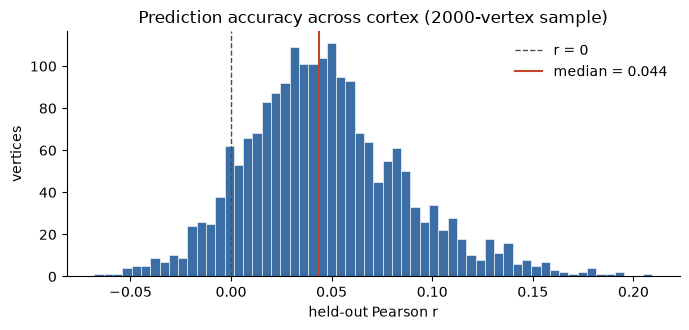

r > 0.05: 42.4% of vertices
r > 0.10:  9.9% of vertices
r > 0.15:  1.3% of vertices
r > 0.20:  0.1% of vertices


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(per_vertex, bins=60, color='#3b6ea5', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='0.3', linewidth=1, linestyle='--', label='r = 0')
ax.axvline(float(score), color='#c1452b', linewidth=1.5,
           label=f'median = {float(score):.3f}')
ax.set_xlabel('held-out Pearson r')
ax.set_ylabel('vertices')
ax.set_title('Prediction accuracy across cortex (2000-vertex sample)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# How much of cortex is predicted well, rather than on average.
for threshold in (0.05, 0.10, 0.15, 0.20):
    print(f'r > {threshold:.2f}: {(per_vertex > threshold).mean():5.1%} of vertices')

## The full benchmark

Scoring all 20484 vertices takes about 140 seconds and peaks near 8 GB:

```python
score = brainscore.score('gpt2', 'LeBel2023-UTS03-encoding')
```

GPT-2 on the full set gives a median r of **0.0422**, with 89.7% of vertices above zero,
a 99th percentile of 0.162 and a best vertex of 0.263. That shape — most of cortex barely
predicted, a minority predicted well — is what a whole-brain benchmark is meant to show,
and it is information a region-masked benchmark discards.

### What this does not yet establish

**One participant.** UTS03 only. Nothing here separates properties of this brain from
properties of brains.

**No noise ceiling.** With one presentation per story, the reliable fraction of each
vertex's signal is unknown, so a low correlation cannot be attributed to the model rather
than to the measurement. LeBel's design does include repeated stories; adding them would
make these scores normalisable and comparable to ceiling-normalised benchmarks.

**No anatomy.** The source pickle carries no vertex-to-region mapping, so vertices are
identified only by index. Attaching a surface atlas would turn the tail of the histogram
above into a statement about which areas are predicted, which is the more interesting
question.

**One layer.** GPT-2 is read at its final block, `h.11`. Middle layers are typically more
predictive of brain data, so this is a lower bound on what the model can do.